In [3]:
import pandas as pd



sleep_health_data = pd.read_csv("Sleep_health_and_lifestyle_dataset.csv")
sleep_health_data = sleep_health_data.drop(columns=["Person ID"])
sleep_health_data = sleep_health_data.dropna()  

# Encode categorical variables
sleep_health_data = pd.get_dummies(sleep_health_data, columns=["Gender", "Occupation", "BMI Category", "Sleep Disorder"], drop_first=True)

#splitting blood pressure so we don't have any issues reading the numbers
sleep_health_data[["Systolic", "Diastolic"]] = sleep_health_data["Blood Pressure"].str.split("/", expand=True).astype(float)
sleep_health_data = sleep_health_data.drop(columns=["Blood Pressure"])

In [4]:
#we are gonna train an ml model with linear regression, so we are gonna weight the data from each of the columns in the data with a bias each time 
#and overtime after being trained when we give the data for one person, it predicts a sleep score number.


import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error

#with this being my first time working on a linear regression model, I am going to use sklearn as it is the one best suited for this task.

#now here are the features and the target
inputs = sleep_health_data.drop(columns=["Quality of Sleep"])
outputs = sleep_health_data["Quality of Sleep"]

train_inputs, inputs_test, train_outputs, outputs_test = train_test_split(inputs, outputs, test_size=0.2, random_state=42)

#here we are training the model through the 374 rows of data in the set
model = RandomForestRegressor(random_state=42)
model.fit(train_inputs, train_outputs)


output_pred = model.predict(inputs_test)

# displaying some results r^2 represents how much variation the model has in predicting, basically how much it guesses, 0 means it guesses completely and 1 means that it explains everything perfectly
print("R²:", r2_score(outputs_test, output_pred))
# RMSE represents the shows the difference in predicted sleep scores vs the actual ones 
print("RMSE:", mean_squared_error(outputs_test, output_pred, squared=False))

R²: 0.9251294642857143
RMSE: 0.36178321792779927


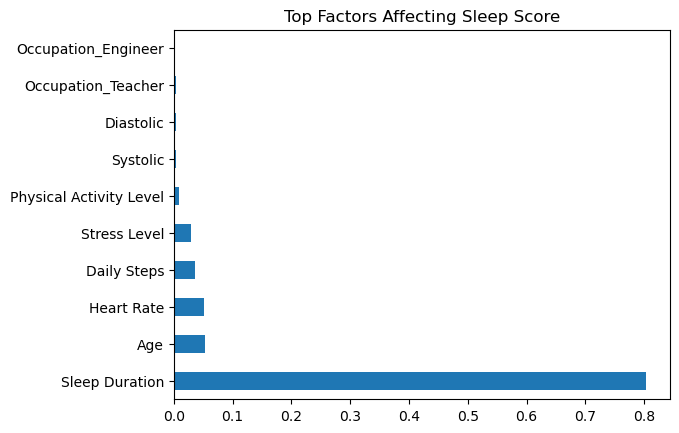

In [5]:
# Im happy to see the results here with variation being minimal, the RMSE is good but there is still definetely room for improvement
# now that we have ran and tested a model lets check the biases it calculated do determine which information affects the sleep score the most

import pandas as pd
import matplotlib.pyplot as plt

feat_importances = pd.Series(model.feature_importances_, index=inputs.columns)
feat_importances.nlargest(10).plot(kind='barh')
plt.title("Top Factors Affecting Sleep Score")
plt.show()


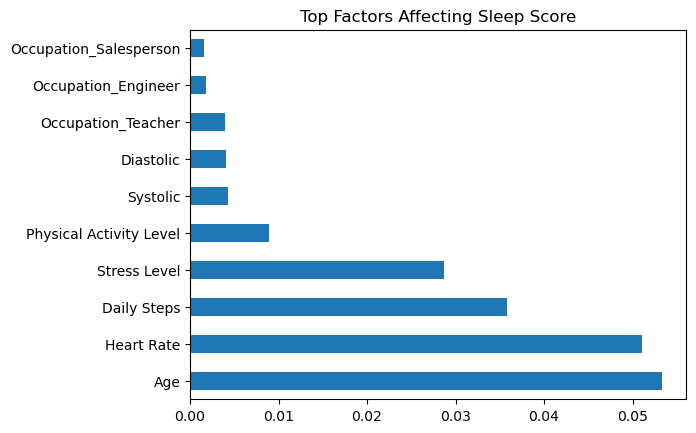

In [6]:
#obviously we can see the thing that gives the most bias towards sleep score is sleep duration, and this obviously makes sense. 
#It is true that quality sleep in shorter spans might be slightly better but the number of hours you sleep always matters a lot
#one thing I think will help us get a better idea of the data set is comparing factors other than sleep duration to get a better understanding of the other information.

feat_importances = pd.Series(model.feature_importances_, index=inputs.columns)
feat_importances = feat_importances.drop("Sleep Duration") # here we are dropping the sleep duration bias to understand the other values of the data set better
feat_importances.nlargest(10).plot(kind='barh')

plt.title("Top Factors Affecting Sleep Score")
plt.show()



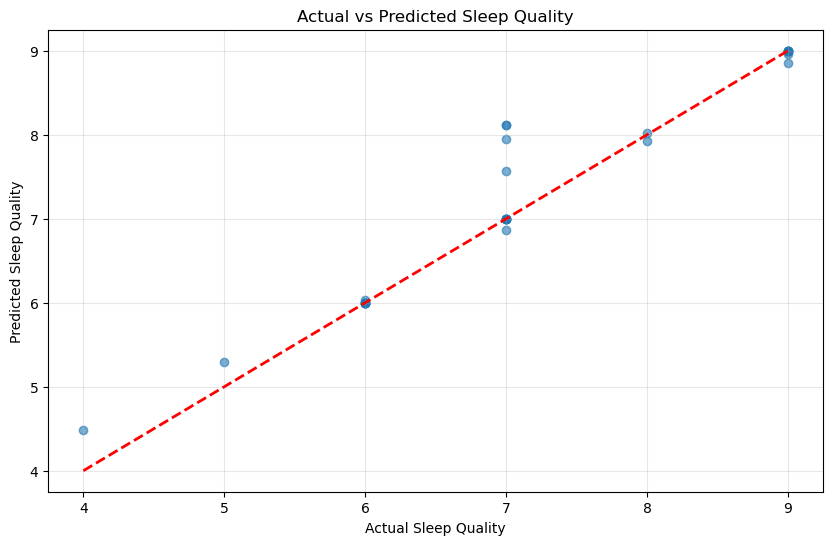

In [8]:
plt.figure(figsize=(10, 6))
plt.scatter(outputs_test, output_pred, alpha=0.6)
plt.plot([outputs_test.min(), outputs_test.max()], [outputs_test.min(), outputs_test.max()], 'r--', lw=2)
plt.xlabel('Actual Sleep Quality')
plt.ylabel('Predicted Sleep Quality')
plt.title('Actual vs Predicted Sleep Quality')
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
#this mostly matches the  normal line but we can see that there is a deviation in predictions for 7 points in actual sleep quality vs predicted.

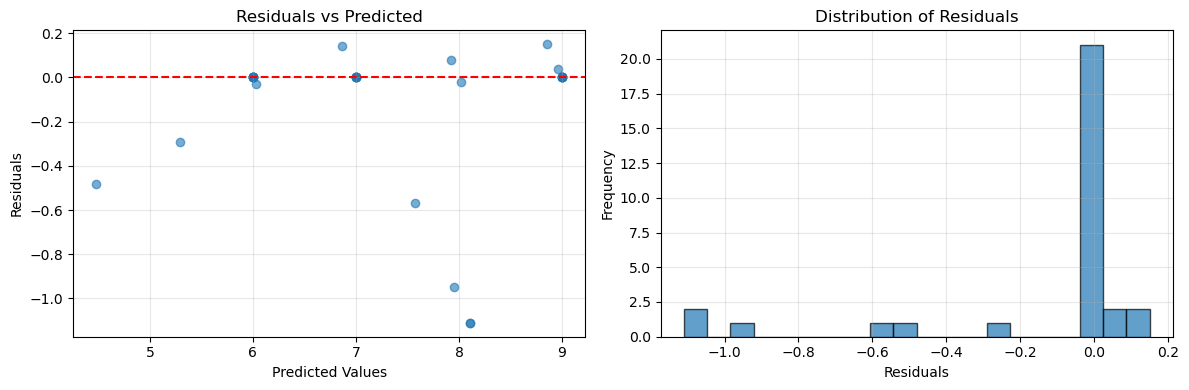

In [9]:
residuals = outputs_test - output_pred

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.scatter(output_pred, residuals, alpha=0.6)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residuals vs Predicted')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.hist(residuals, bins=20, alpha=0.7, edgecolor='black')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.title('Distribution of Residuals')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# for the first graph we see a mostly random scatter and not a specific pattern which is good to see, my main concern would be that the variance is slightly higher between 7 to 8 much more than e

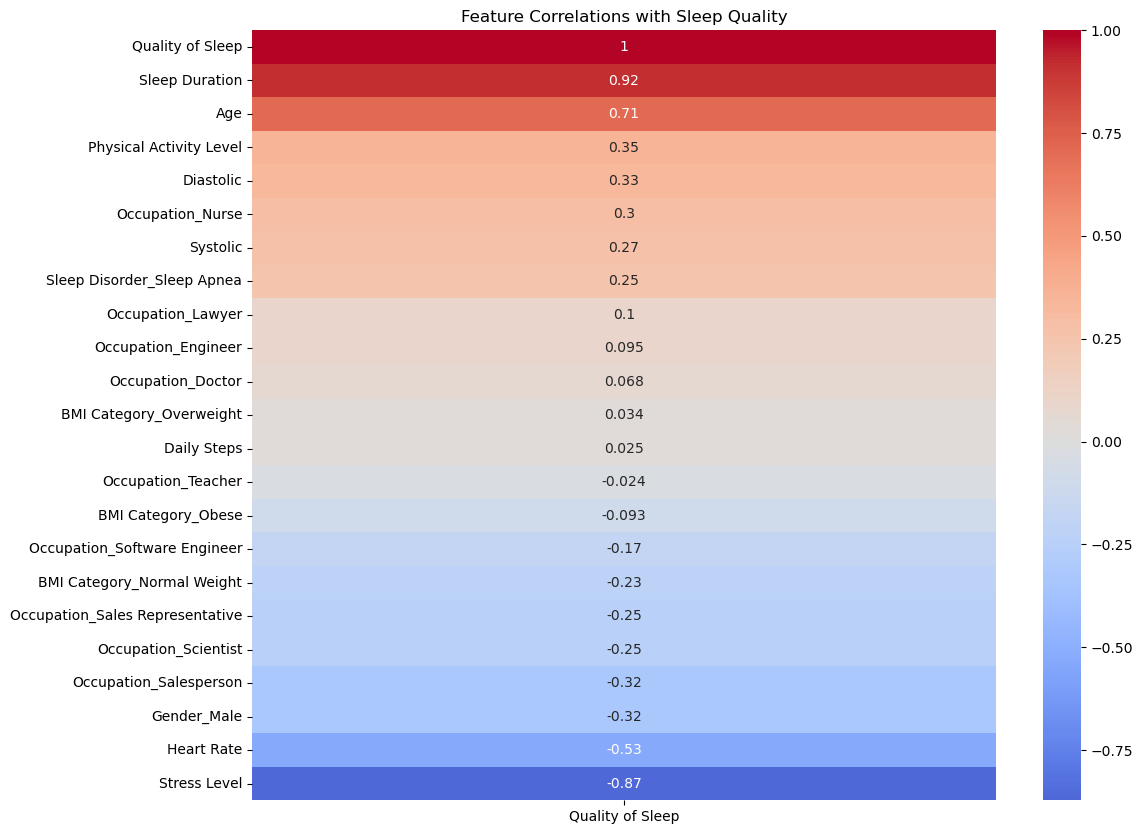

In [10]:
import seaborn as sns
import numpy as np

plt.figure(figsize=(12, 10))
correlation_matrix = sleep_health_data.corr()
sns.heatmap(correlation_matrix[['Quality of Sleep']].sort_values('Quality of Sleep', ascending=False),
            annot=True, cmap='coolwarm', center=0)
plt.title('Feature Correlations with Sleep Quality')
plt.show()

In [ ]:
# here is a colored version with more details of correlation with sleep quality.

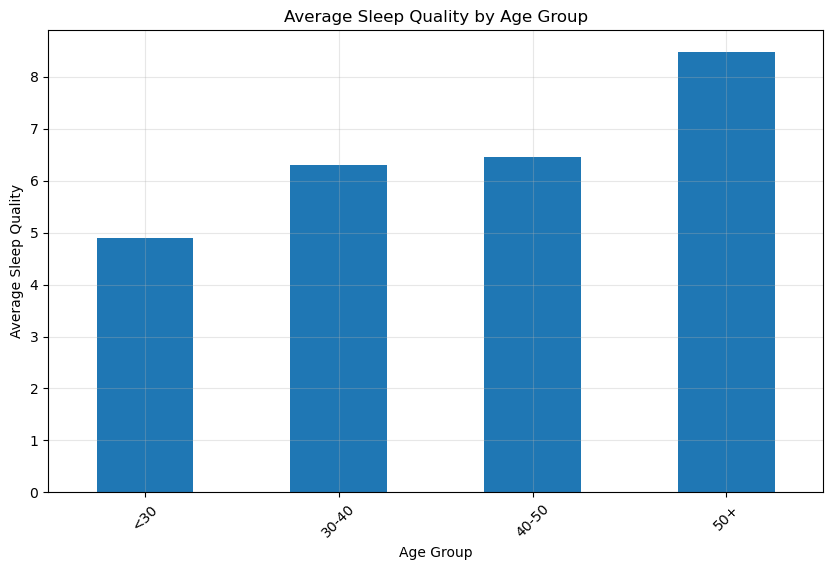

In [11]:
sleep_health_data['Age Group'] = pd.cut(sleep_health_data['Age'], 
                                       bins=[0, 30, 40, 50, 100], 
                                       labels=['<30', '30-40', '40-50', '50+'])

plt.figure(figsize=(10, 6))
sleep_health_data.groupby('Age Group')['Quality of Sleep'].mean().plot(kind='bar')
plt.title('Average Sleep Quality by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Average Sleep Quality')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# So based off of this data I am gonna make a prediction that sleep quality is higher with older people since they have less energy, I have seen myself being a energetic young kid keeps me awake at night sometimes but I suppose when you get older and have less energy it will be easier to sleep. I think we also tend to see older people need more sleep to function how they used to before so this makes sense.

